In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [14]:
data = {
    'Equioment' : ['Transformer-1', 'Transformer-2',
                   'Circuit Breaker-1', 'Circuit Breaker-2',
                   'Cable-1', 'Cable-2'],
    'Voltage_kV' : [11.0, 11.2, 11.8, 11.5, 10.5, 11.8],
    'Current_A': [150, 160, 145, 180, 140, 190],
    'Temp_C'   : [45, 52, 38, 65, 35, 70],
    'Status'   : ['Normal', 'Normal', 'Normal','Warning','Normal','Critical']
}
df = pd.DataFrame(data)
df.to_excel('Substation_data.xlsx', index=False)
print("Excel file created!")
print(df)

Excel file created!
           Equioment  Voltage_kV  Current_A  Temp_C    Status
0      Transformer-1        11.0        150      45    Normal
1      Transformer-2        11.2        160      52    Normal
2  Circuit Breaker-1        11.8        145      38    Normal
3  Circuit Breaker-2        11.5        180      65   Warning
4            Cable-1        10.5        140      35    Normal
5            Cable-2        11.8        190      70  Critical


In [10]:
!pip install openpyxl

In [20]:
# Read the Excel file
df=pd.read_excel('Substation_data.xlsx')

print("SUBSTATION DATA LOADED!")
print("-"*40)
print(df)
print("-"*40)

# Numpy Calculation
print("VOLTAGE Analysis")
print("Average:", np.mean(df['Voltage_kV']),"kV")
print("Highest:", np.max(df['Voltage_kV']),"kV")
print("Lowest:", np.min(df['Voltage_kV']), "kV")
print("-"*40)
print("TEMPRATURE ANALYSIS")
print("Average:", np.mean(df['Temp_C']),"C")
print("Highest:", np.max(df['Temp_C']),"C")
print("Lowest:", np.min(df['Temp_C']),"C")




SUBSTATION DATA LOADED!
----------------------------------------
           Equioment  Voltage_kV  Current_A  Temp_C    Status
0      Transformer-1        11.0        150      45    Normal
1      Transformer-2        11.2        160      52    Normal
2  Circuit Breaker-1        11.8        145      38    Normal
3  Circuit Breaker-2        11.5        180      65   Warning
4            Cable-1        10.5        140      35    Normal
5            Cable-2        11.8        190      70  Critical
----------------------------------------
VOLTAGE Analysis
Average: 11.299999999999999 kV
Highest: 11.8 kV
Lowest: 10.5 kV
----------------------------------------
TEMPRATURE ANALYSIS
Average: 50.833333333333336 C
Highest: 70 C
Lowest: 35 C


In [25]:
print("FAULT DETECTION REPORT")
print("-"*40)

for index, row in df.iterrows():
    equipment = row['Equioment']
    voltage = row['Voltage_kV']
    temp = row['Temp_C']
    current= row['Current_A']

    if temp > 60:
        print("CRITICAL:", equipment, "Temp", temp, "C")
    elif temp > 50:
        print("WARNING:", equipment, "Temp", temp, "C")
    else:
        print("NORMAL:", equipment, "Temp", temp, "C")

    print ("-"*40)
    print ("INSPECTION REQUIRED FOR")

FAULT DETECTION REPORT
----------------------------------------
NORMAL: Transformer-1 Temp 45 C
----------------------------------------
INSPECTION REQUIRED FOR
----------------------------------------
INSPECTION REQUIRED FOR
NORMAL: Circuit Breaker-1 Temp 38 C
----------------------------------------
INSPECTION REQUIRED FOR
CRITICAL: Circuit Breaker-2 Temp 65 C
----------------------------------------
INSPECTION REQUIRED FOR
NORMAL: Cable-1 Temp 35 C
----------------------------------------
INSPECTION REQUIRED FOR
CRITICAL: Cable-2 Temp 70 C
----------------------------------------
INSPECTION REQUIRED FOR


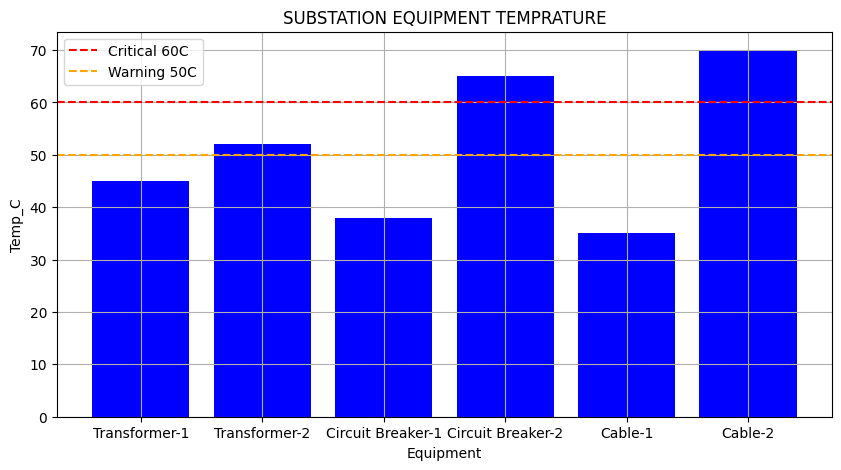

In [29]:
plt.figure(figsize=(10, 5))
plt.bar (df['Equioment'],df['Temp_C'],color='blue')
plt.axhline(y=60, color='red', linestyle='--', label='Critical 60C')
plt.axhline(y=50, color='orange', linestyle='--', label='Warning 50C')
plt.title ('SUBSTATION EQUIPMENT TEMPRATURE')
plt.xlabel('Equipment')
plt.ylabel('Temp_C')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
print(df.columns)

Index(['Equioment', 'Voltage_kV', 'Current_A', 'Temp_C', 'Status'], dtype='object')


In [34]:
print ("FINAL SUBSTATION SUMMARY")
print ("-"*40)
total = len (df)
critical = len(df[df['Temp_C'] > 60])
warning = len(df[df['Temp_C'] > 50]) - critical
normal = total - critical - warning
print("Total Equipment:", total)
print("Critical:", critical)
print("Warning:", warning)
print("Normal:", normal)
print("-" *40)
if critical > 0:
    print("Action Required Immidiately!")
elif warning > 0:
    print("Monitor closely!")
else:
    print("No Action Required!")

FINAL SUBSTATION SUMMARY
----------------------------------------
Total Equipment: 6
Critical: 2
Normal: 3
----------------------------------------
Action Required Immidiately!
